# Self-report vs Behavior task Correlations

### Setup

Load [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension. 
This enables us to modify `.py` source files and reintegrate them into the notebook.


In [1]:
%load_ext autoreload
%autoreload 2

Import libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

from questionnaires import load_survey_results
from pedestrian_stats import build_pedestrian_task_results, crosswalk_statistics
from behavior_tasks import build_behavioral_task_results

/Users/jinwoojeong/miniconda3/envs/pedestrian_analysis/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Build dataframe

In [3]:
df = load_survey_results(test = True)
# TODO: 데이터 부족으로 인한 임시방편. 향후 현실적인 데이터로 대체.
df.loc[3, "subj_id"] = 502
df.loc[4, "subj_id"] = 1
subj_ids = df["subj_id"].to_list()

df = build_pedestrian_task_results(df, subj_ids)
df = build_behavioral_task_results(df, subj_ids)

df.head()


Total Subjects: 3 ([100, 101, 102])
reversing BIS_1: [2, 4, 4] => [3, 1, 1]
reversing STAI_1: [4, 4, 4] => [1, 1, 1]
reversing CES-D_4: [4, 3, 2] => [1, 2, 3]


,subj_id,age,gender,school_year,BIS,BIS_motor,BIS_nonplanning,BIS_attentional,STAI,STAI_S,...,action_Nothing_cnt,action_UP_cnt,action_DOWN_cnt,action_RIGHT_cnt,action_LEFT_cnt,visited_tile_cnt_mean,visited_unique_tile_cnt_mean,visited_tile_unique_ratio_mean,DDT_mean_log_k,CRA_mean_alpha
0,100,29,2,16,77,30,25,22,96,45,...,404,138,0,650,656,53.962963,18.148148,0.344531,-6.945853,0.851175
1,502,1001,2,12,79,31,25,23,104,51,...,26,2030,48,348,569,29.520000,28.070000,0.957723,-4.945853,0.751175
2,1,1901,1,1234,80,36,24,20,109,56,...,26,2030,48,348,569,29.520000,28.070000,0.957723,-2.945853,1.111751


Utils

In [4]:
def scatter_plot_with_line_regression(plot, x, y, xlabel, ylabel, title):
    plot.scatter(x, y)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept
    plot.plot(line_x, line_y, color="red")

    plot.set_xlabel(xlabel)
    plot.set_ylabel(ylabel)
    plot.set_title(f"{title}\nr={r_value:.3f}")

## Self-report vs Traditional Behavior Tasks

### DDT: Delay Discounting Task
- DDT: Discounting Rate `k`
- BIS: impulsivity

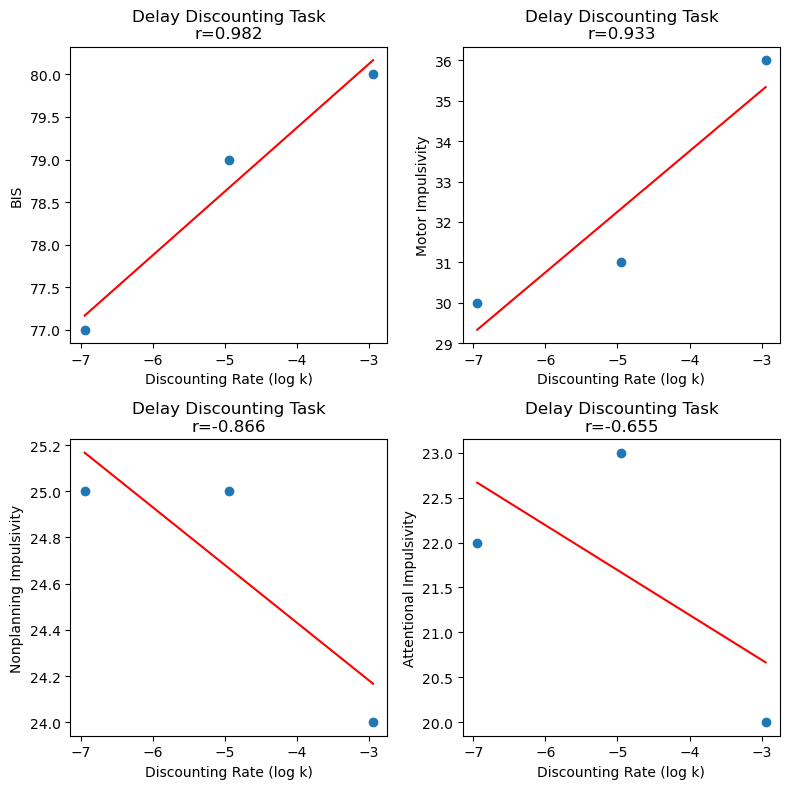

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
title = "Delay Discounting Task"
x = df["DDT_mean_log_k"]
xlabel = "Discounting Rate (log k)"
scatter_plot_with_line_regression(axes[0, 0], x, df["BIS"], xlabel, "BIS", title)
scatter_plot_with_line_regression(axes[0, 1], x, df["BIS_motor"], xlabel, "Motor Impulsivity", title)
scatter_plot_with_line_regression(axes[1, 0], x, df["BIS_nonplanning"], xlabel, "Nonplanning Impulsivity", title)
scatter_plot_with_line_regression(axes[1, 1], x, df["BIS_attentional"], xlabel, "Attentional Impulsivity", title)

plt.tight_layout()
plt.show()

### CRA: Choice under Risk and Ambiguity Task

- CRA: risk preference parameter `alpha`
- DOSPERT: Risk Taking

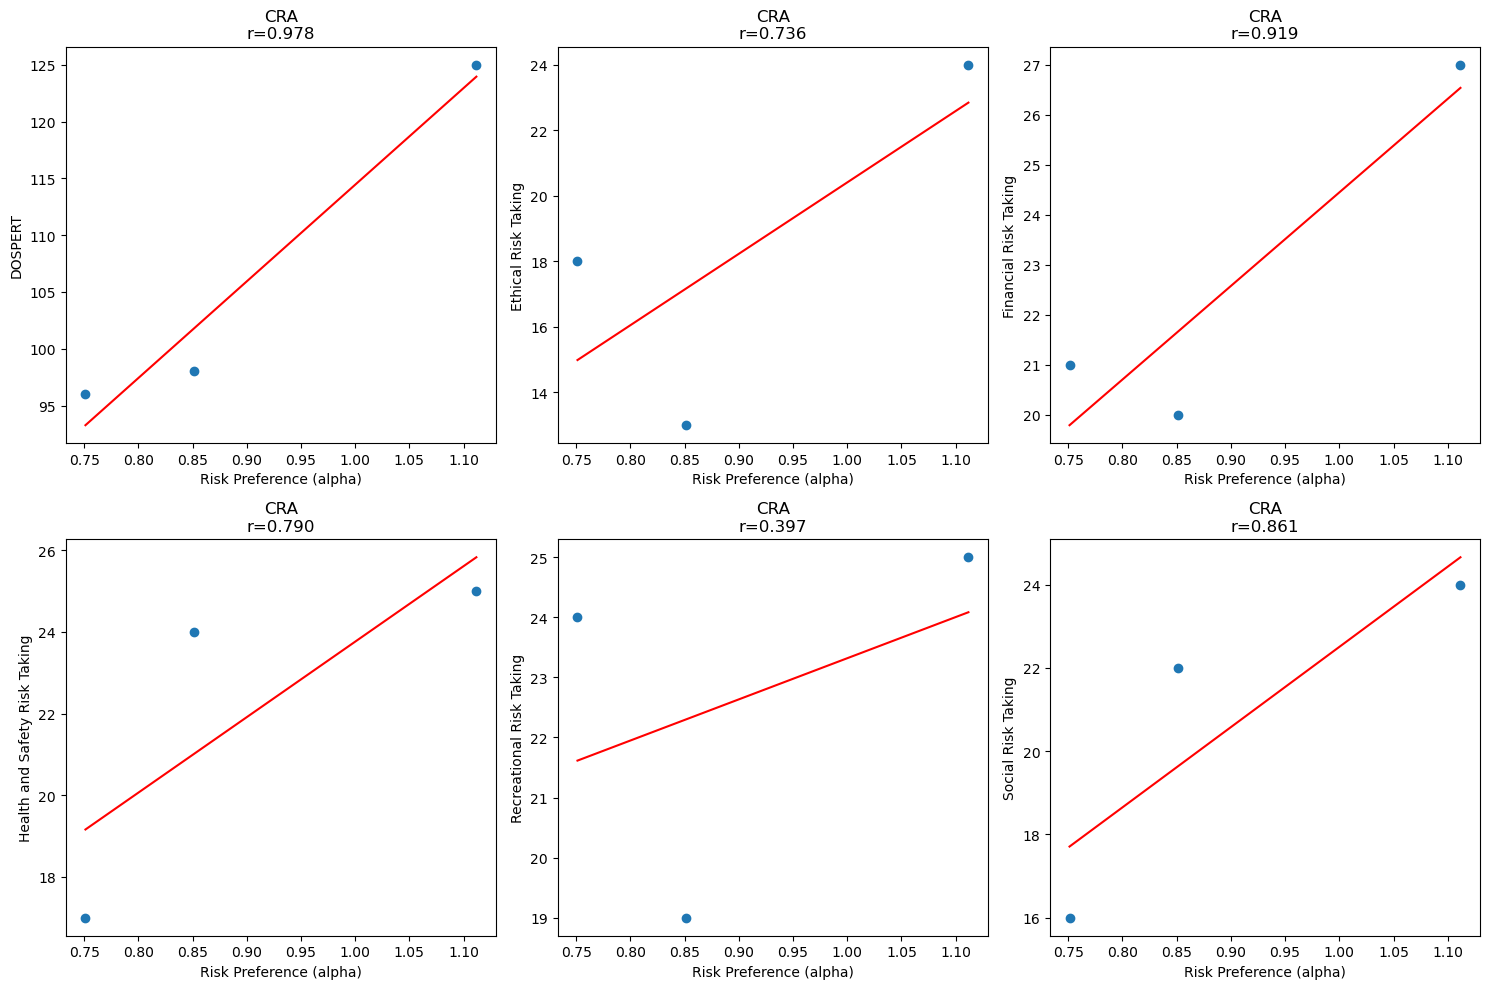

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
title = "CRA"
x = df["CRA_mean_alpha"]
xlabel = "Risk Preference (alpha)"
scatter_plot_with_line_regression(axes[0, 0], x, df["DOSPERT"], xlabel, "DOSPERT", title)
scatter_plot_with_line_regression(axes[0, 1], x, df["DOSPERT_ETH"], xlabel, "Ethical Risk Taking", title)
scatter_plot_with_line_regression(axes[0, 2], x, df["DOSPERT_FIN"], xlabel, "Financial Risk Taking", title)
scatter_plot_with_line_regression(axes[1, 0], x, df["DOSPERT_HEA"], xlabel, "Health and Safety Risk Taking", title)
scatter_plot_with_line_regression(axes[1, 1], x, df["DOSPERT_REC"], xlabel, "Recreational Risk Taking", title)
scatter_plot_with_line_regression(axes[1, 2], x, df["DOSPERT_SOC"], xlabel, "Social Risk Taking", title)
plt.tight_layout()
plt.show()

## Self-report vs Pedestrian Task

### Pedestrian Task Scores
- total score
- best score
- average score

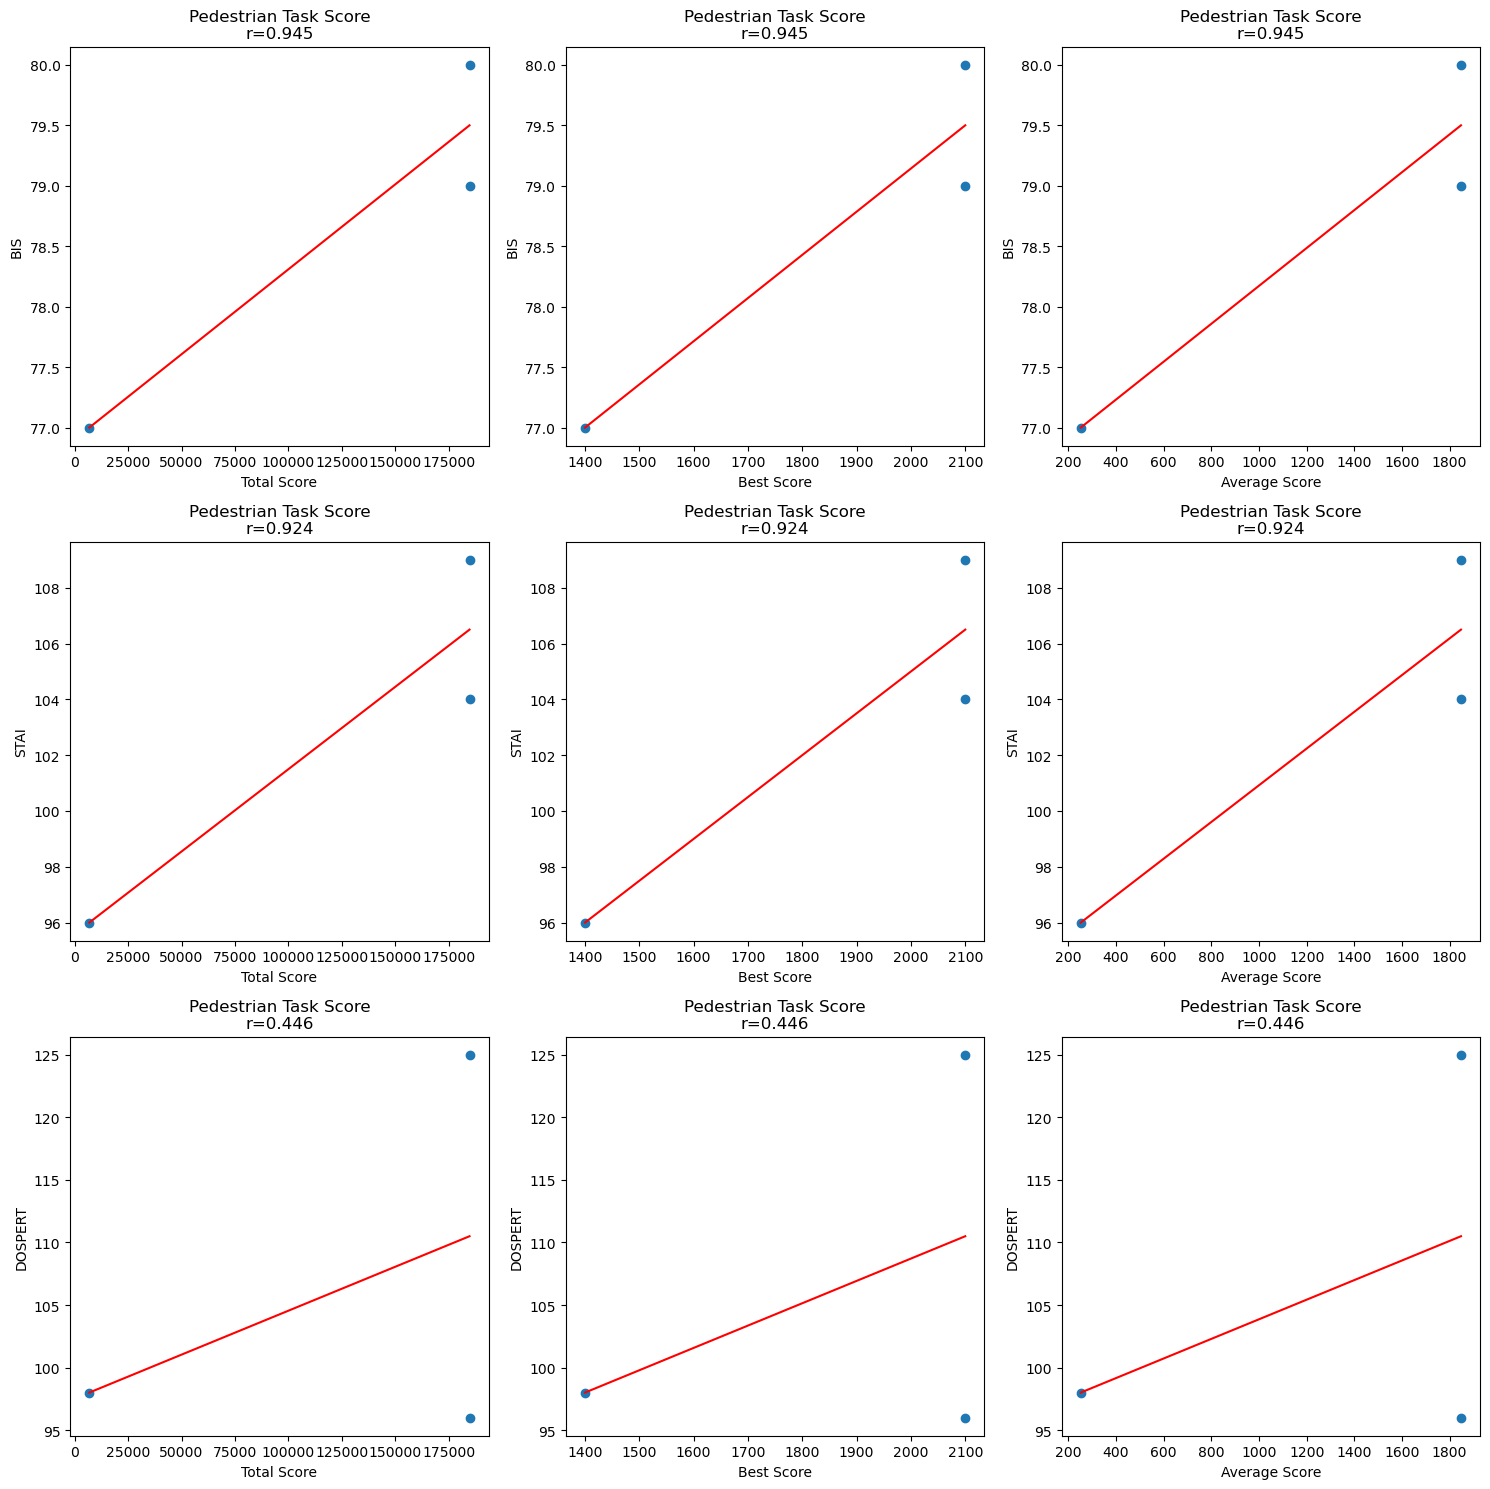

In [7]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]
row_count = len(questionnaires)

fig, axes = plt.subplots(row_count, 3, figsize=(15, 5 * row_count))
for i in range(row_count):
    questionnaire = questionnaires[i]
    scores = ["total_score_full", "best_score_full", "average_score_full"]
    xlabels = ["Total Score", "Best Score", "Average Score"]
    for j in range(3):
        x = df[scores[j]]
        y = df[questionnaire]
        scatter_plot_with_line_regression(axes[i, j], x, y, xlabels[j], questionnaire, title="Pedestrian Task Score")

plt.tight_layout()
plt.show()

### Crosswalk usage
- TODO

### Game over status
- TODO

### Locomotor Statistics
- Action Proportions
- Number of visited tiles